In [38]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor

In [70]:
df=pd.read_csv("data/raw.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [71]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [72]:
X=df.drop(["math score"],axis=1)


In [73]:
y=df["math score"]

In [74]:
num_feature=X.select_dtypes(exclude="object").columns
cat_feature=X.select_dtypes(include="object").columns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transform=StandardScaler()
oh_transform=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transform,cat_feature),
         ("StandardScaler",numeric_transform,num_feature)
    ]
)

In [75]:
X=preprocessor.fit_transform(X)

In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=45)

In [77]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2=r2_score(true,predicted)
    return mae,mse,r2

In [80]:
models={
    "LinearRegression": LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "k-neigbhours":KNeighborsRegressor(),
    "decision tree": DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(n_estimators=20),
    "XGBRegressor":XGBRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=True)
    
}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)
    
    #prediction
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    
    model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("----------model preformace for training set--------")
    print("root mean squared error: {:.4f}".format(model_train_rmse))
    print("mean_absolute_error : {:.4f}".format(model_train_mae))
    print("r2 score: {:.4f}".format(model_train_r2))
    
    print("------------------------------------------------------")
    print("----------- model preformace for test set --------------")
    print("root mean squared error: {:.4f}".format(model_test_rmse))
    print("mean_absolute_error : {:.4f}".format(model_test_mae))
    print("r2 score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print('='*35)
    print("\n")
    

LinearRegression
----------model preformace for training set--------
root mean squared error: 27.7083
mean_absolute_error : 4.1618
r2 score: 0.8809
------------------------------------------------------
----------- model preformace for test set --------------
root mean squared error: 30.6018
mean_absolute_error : 4.4857
r2 score: 0.8590


Lasso
----------model preformace for training set--------
root mean squared error: 42.0652
mean_absolute_error : 5.0814
r2 score: 0.8192
------------------------------------------------------
----------- model preformace for test set --------------
root mean squared error: 47.2559
mean_absolute_error : 5.5884
r2 score: 0.7822


Ridge
----------model preformace for training set--------
root mean squared error: 27.7108
mean_absolute_error : 4.1607
r2 score: 0.8809
------------------------------------------------------
----------- model preformace for test set --------------
root mean squared error: 30.6470
mean_absolute_error : 4.4898
r2 score: 0.8588



In [79]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["model names", "r2_score"]).sort_values(by="r2_score", ascending=False)


,model names,r2_score
0,LinearRegression,0.858972
2,Ridge,0.858763
8,CatBoostRegressor,0.827487
5,RandomForestRegressor,0.811745
7,AdaBoostRegressor,0.799999
6,XGBRegressor,0.783969
1,Lasso,0.782221
3,k-neigbhours,0.771130
4,decision tree,0.659635


In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)

score_value = r2_score(y_test, y_pred) * 100
print(f"R² Score (Accuracy): {score_value:.2f}%")


R² Score (Accuracy): 85.90%


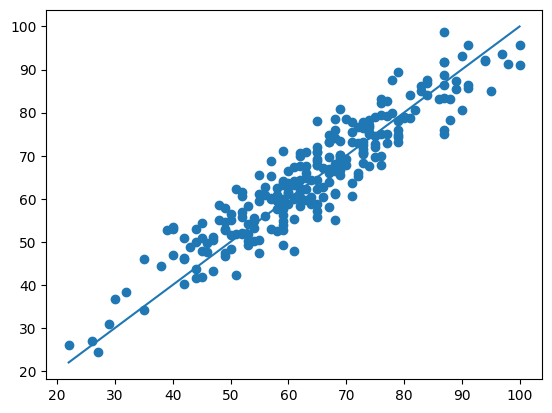

In [103]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])

In [105]:
pred=pd.DataFrame({
    "actutal":y_test,
    "predicted":y_pred,
    "diff":y_test-y_pred
})
pred

,actutal,predicted,diff
726,65,70.975492,-5.975492
243,59,57.694996,1.305004
342,69,65.461291,3.538709
976,60,61.538920,-1.538920
919,91,95.641960,-4.641960
...,...,...,...
166,53,51.808948,1.191052
503,95,85.089913,9.910087
100,79,74.279063,4.720937
828,69,69.121480,-0.121480
